# Projet 1 – Analyse d’actions françaises

## Objectif
Analyser l’évolution des cours de trois entreprises françaises (BNP Paribas, LVMH, TotalEnergies)
entre 2020 et 2025, afin d’étudier leur rendement, volatilité et corrélation.

## Données
Les données proviennent de Yahoo Finance via le module `yfinance`.


In [25]:
# import + lecture CSV

import pandas as pd
import os

data_dir = "../data/raw/"
tickers = ["BNP.PA", "MC.PA", "TTE.PA"]
cols = ['Date', 'Price', 'Close', 'High', 'Low', 'Open', 'Volume']

price_df = pd.DataFrame()

for ticker in tickers:
    file_path = os.path.join(data_dir, f"{ticker}.csv")
    try:
        # Lecture brute
        df = pd.read_csv(file_path, skiprows=2, header=None, names=cols)

        # Filtrage des lignes valides
        df = df[df['Date'].str.match(r'\d{4}-\d{2}-\d{2}')]

        # Conversion en datetime
        df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d')
        df.set_index('Date', inplace=True)

        # Extraction du prix
        price_df[ticker] = df['Price']

        print(f"Données chargées pour {ticker}")
    except Exception as e:
        print(f"Erreur avec {ticker} : {e}")

Données chargées pour BNP.PA
Données chargées pour MC.PA
Données chargées pour TTE.PA


## Import et lecture des données
Nous avons chargé les prix journaliers ajustés pour BNP Paribas, LVMH et TotalEnergies depuis des fichiers CSV.  
Chaque fichier contient les colonnes `Price`, `Open`, `High`, `Low`, `Close`, `Volume`.  
Le code :
- Filtre les lignes valides correspondant à une date (`YYYY-MM-DD`),
- Convertit les dates en format `datetime`,
- Définit la date comme index,
- Crée un DataFrame unique `price_df` avec toutes les actions pour analyse.

In [26]:
# Vérification des données

price_df.info()
price_df.head()
price_df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1539 entries, 2019-01-02 to 2024-12-31
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   BNP.PA  1539 non-null   float64
 1   MC.PA   1539 non-null   float64
 2   TTE.PA  1539 non-null   float64
dtypes: float64(3)
memory usage: 48.1 KB


BNP.PA    0
MC.PA     0
TTE.PA    0
dtype: int64

## Vérification des données
- `info()` montre que nous avons 1539 entrées par action, sans valeurs manquantes.
- `head()` permet de voir les premières lignes du tableau.
- `isna().sum()` confirme qu'il n'y a aucune donnée manquante.
Cette vérification est essentielle avant toute analyse pour éviter les erreurs.

In [27]:
# Gestion des valeurs manquantes

# Option 1 : conserver uniquement les dates où toutes les colonnes ont des valeurs
price_df = price_df.dropna(how='any')

# Option 2 (si tu veux forward-fill) :
# price_df = price_df.fillna(method='ffill').dropna()

## Gestion des valeurs manquantes
Ici, nous choisissons de supprimer toute ligne contenant une valeur manquante.  
Alternative possible : utiliser un `forward-fill` (`fillna(method='ffill')`) pour conserver toutes les dates.

In [28]:
# Calcul des rendements

returns = price_df.pct_change().dropna()  # rendement simple
log_returns = np.log(price_df / price_df.shift(1)).dropna()  # rendements log (optionnel)

## Calcul des rendements
- `returns` : rendements simples quotidiens.
- `log_returns` : rendements logarithmiques (utile pour certaines analyses financières).  
Le rendement mesure l’évolution relative du prix d’une action d’un jour à l’autre.

In [29]:
# Statistique descriptive

# Moyennes et volatilités annualisées
mean_daily = returns.mean()                 # moyenne journalière
mean_annual = mean_daily * 252              # approx. annualisation
vol_daily = returns.std()
vol_annual = vol_daily * np.sqrt(252)

print("Rendement annualisé (%) :\n", mean_annual*100)
print("\nVolatilité annualisée (%) :\n", vol_annual*100)

Rendement annualisé (%) :
 BNP.PA    17.813936
MC.PA     20.754594
TTE.PA    12.655221
dtype: float64

Volatilité annualisée (%) :
 BNP.PA    33.805437
MC.PA     28.998862
TTE.PA    30.118753
dtype: float64


## Rendement et volatilité annualisés
- Le **rendement annualisé** estime le pourcentage moyen de gain par an.
- La **volatilité annualisée** mesure le risque ou l’incertitude du rendement.  
Exemple : LVMH est la plus volatile, reflétant la sensibilité du secteur du luxe.

In [30]:
# Corrélation

corr = returns.corr()
print(corr)

          BNP.PA     MC.PA    TTE.PA
BNP.PA  1.000000  0.517402  0.608685
MC.PA   0.517402  1.000000  0.415389
TTE.PA  0.608685  0.415389  1.000000


## Corrélation des rendements
- La corrélation varie entre -1 et 1.
- Une corrélation élevée entre deux actions indique qu'elles évoluent souvent dans le même sens.
- BNP et TotalEnergies sont modérément corrélées (0.61), LVMH moins.

In [31]:
# Rolling volatility (Vol glissant)
import numpy as np
rolling_vol_30 = returns.rolling(window=30).std() * np.sqrt(252)  # 30 jours -> annualisé

## Volatilité glissante
- Calculée sur une fenêtre de 30 jours pour voir l’évolution du risque dans le temps.
- Utile pour détecter des périodes de marché calme ou turbulentes.

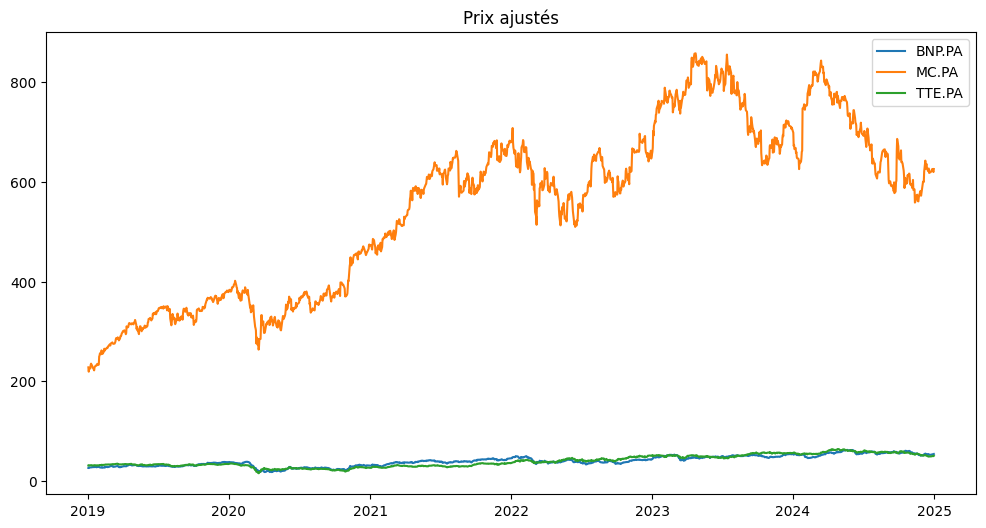

In [32]:
# Graphique 1 : Evolution des prix
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
for col in price_df.columns:
    plt.plot(price_df.index, price_df[col], label=col)
plt.legend()
plt.title("Prix ajustés")
plt.show()

## Graphique : Evolution des prix
Ce graphique montre l'évolution quotidienne du prix des trois actions.  
On observe les tendances générales et les pics/baisses importantes.

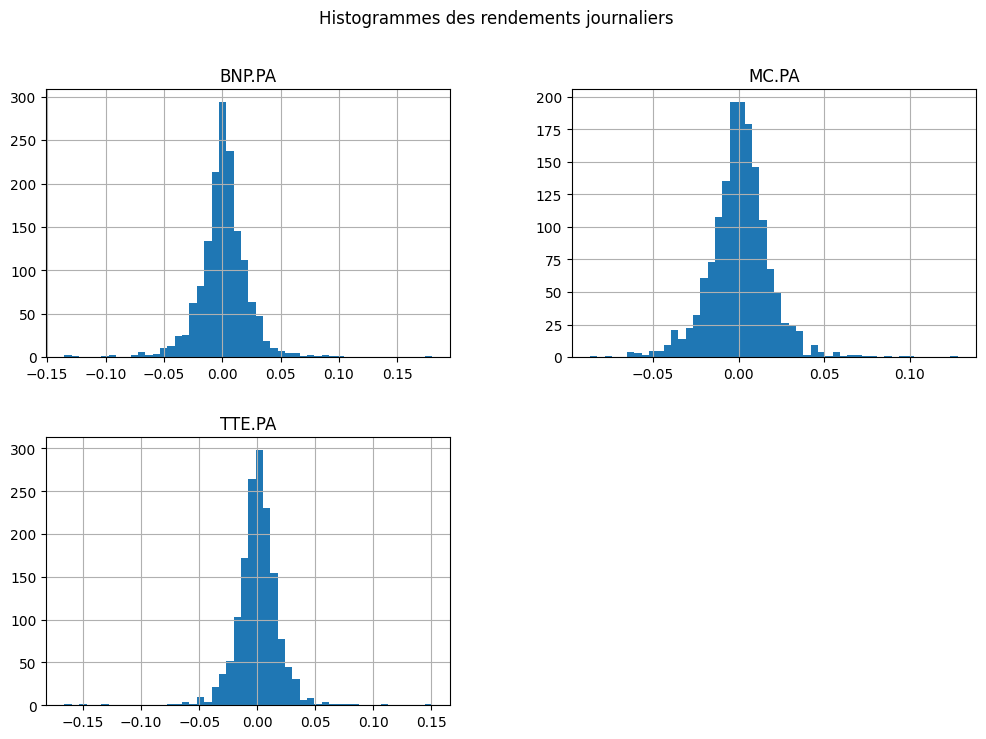

In [33]:
# Graphique 2 : Rendements journaliers (histogrammes)

returns.hist(bins=50, figsize=(12,8))
plt.suptitle("Histogrammes des rendements journaliers")
plt.show()

## Graphique : Rendements journaliers
Ce graphique montre l'évolution quotidienne du prix des trois actions.

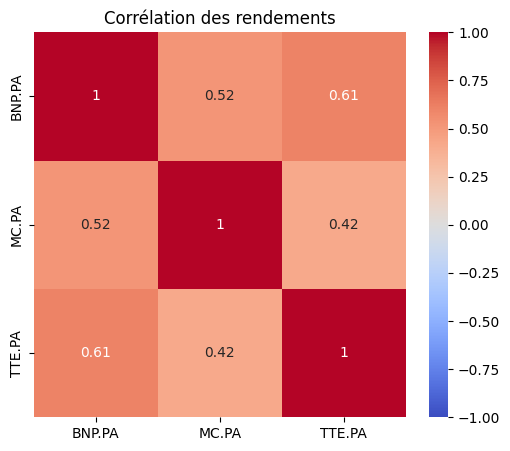

In [34]:
# Graphique 3 : Heatmap de corrélations
import seaborn as sns
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Corrélation des rendements")
plt.show()

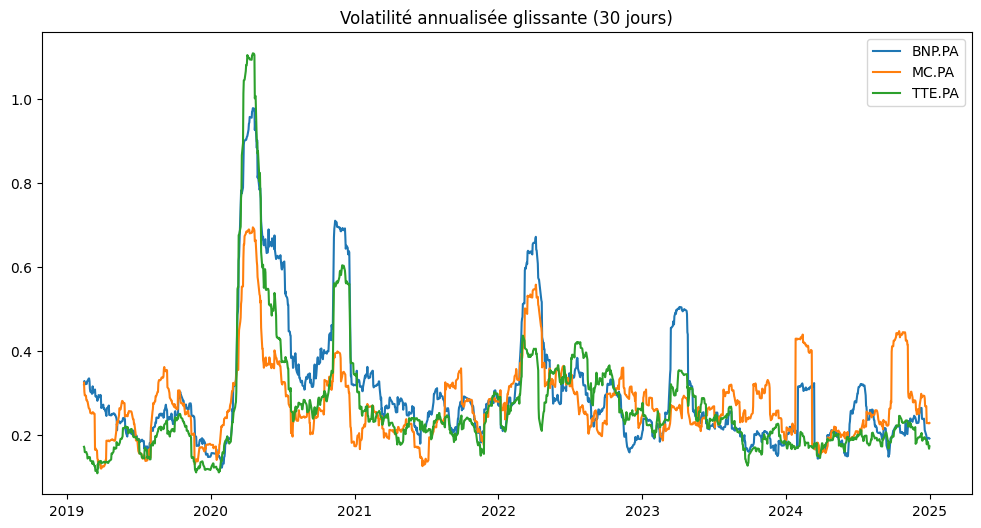

In [35]:
# Graphique 4 : Volatilité glissante (rolling std)
plt.figure(figsize=(12,6))
for col in rolling_vol_30.columns:
    plt.plot(rolling_vol_30.index, rolling_vol_30[col], label=col)
plt.legend()
plt.title("Volatilité annualisée glissante (30 jours)")
plt.show()

## Conclusion
- LVMH est l’action la plus volatile, reflétant une sensibilité forte du secteur du luxe.
- BNP et TotalEnergies sont plus corrélées, ce qui peut limiter la diversification.
- Un portefeuille équilibré entre ces titres pourrait réduire le risque total.

Ce projet montre comment Python peut être utilisé pour explorer et interpréter des données financières.